# Projeto FarmTech: Detecção de Cães e Gatos
**Alunos:** Carla Donato Maximo (RM: 564845) e Ana Cornachi (RM: 564678)

## Objetivo
Demonstrar o potencial da visão computacional usando YOLO para detectar cachorros e gatos, aplicável em:
- Saúde animal
- Segurança patrimonial
- Controle de acessos
- Análise comportamental

## Dataset
- **Treino**: 64 imagens (32 cachorro + 32 gato)
- **Validação**: 8 imagens (4 cachorro + 4 gato)
- **Teste**: 8 imagens (4 cachorro + 4 gato)
- **Total**: 80 imagens





## 1. Coleta e Organização do Dataset
Nesta etapa, o objetivo foi criar um conjunto de dados robusto para treinar e avaliar o modelo.
* **Classes escolhidas:** `cachorro` e `gato`.
* **Total de imagens:** 80 (40 por classe).
* **Divisão do dataset:**
    * **Treino:** 64 imagens (32 de cada classe).
    * **Validação:** 8 imagens (4 de cada classe).
    * **Teste:** 8 imagens (4 de cada classe).

A estrutura de pastas foi organizada no Google Drive para ser compatível com o padrão exigido pelo YOLOv5, separando imagens e rótulos...

## 2. Rotulação das Imagens com Make Sense AI
Para ensinar o modelo a localizar os objetos, as imagens dos conjuntos de treino e validação foram rotuladas utilizando a ferramenta online Make Sense AI. O processo consistiu em desenhar caixas delimitadoras (bounding boxes) ao redor de cada animal e atribuir o rótulo correto ('cachorro' ou 'gato'). As anotações foram exportadas no formato YOLO e salvas no Google Drive.

## 3. Configuração do Ambiente no Google Colab
O ambiente foi preparado para o treinamento executando os seguintes passos:
* **Conexão com o Google Drive:** Para acessar nosso dataset.
* **Clone do Repositório YOLOv5:** Para obter os scripts de treinamento e detecção.
* **Instalação de Dependências:** Para garantir que todas as bibliotecas necessárias estivessem instaladas.

In [3]:
# Importando a biblioteca do Google Drive
from google.colab import drive

# Conecta o ambiente do Colab ao Google Drive para acessar o dataset
drive.mount('/content/drive')

Mounted at /content/drive


In [10]:
# Baixando todo o projeto YOLOv5 do GitHub para o ambiente Colab
!git clone https://github.com/ultralytics/yolov5

Cloning into 'yolov5'...
remote: Enumerating objects: 17608, done.
remote: Counting objects: 100% (15/15), done.
remote: Compressing objects: 100% (13/13), done.
remote: Total 17608 (delta 7), reused 2 (delta 2), pack-reused 17593 (from 2)
Receiving objects: 100% (17608/17608), 16.82 MiB | 17.17 MiB/s, done.
Resolving deltas: 100% (11983/11983), done.


In [11]:
# Navegando para dentro da pasta do YOLOv5 que acabamos de baixar
%cd yolov5

/content/yolov5/yolov5


In [12]:
# Lendo o arquivo requirements.txt e instalando todas as bibliotecas necessárias
!pip install -r requirements.txt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 17.5 MB/s eta 0:00:00


### 3.1. Criação do Arquivo de Configuração do Dataset (`.yaml`)

Para que o script de treinamento do YOLOv5 saiba onde encontrar nossas imagens e o que ele deve aprender a detectar, precisamos criar um arquivo de configuração no formato YAML. Este arquivo funciona como um "mapa de identidade" para o nosso dataset.

Ele contém as seguintes informações cruciais:

* `path`: O caminho absoluto para a pasta raiz do nosso dataset no Google Drive.
* `train`: O caminho relativo (a partir do `path`) para a pasta de imagens de treino.
* `val`: O caminho relativo para a pasta de imagens de validação.
* `nc`: O número de classes (Number of Classes) que nosso modelo precisa aprender. No nosso caso, 2.
* `names`: Uma lista com os nomes exatos de cada classe. A ordem aqui é fundamental, pois define o ID de cada classe (neste caso, `cachorro` será a classe `0` e `gato` será a classe `1`).

Abaixo está o código Python que foi utilizado para criar o arquivo `dataset.yaml` programaticamente, garantindo que os caminhos estivessem corretos.

In [ ]:
# Importando a biblioteca os para manipulação de caminhos de arquivos
import os

# Definindo o caminho para a pasta principal do projeto no Google Drive
drive_project_path = '/content/drive/MyDrive/farmtech_yolo_project'

# Criando o dicionário com as configurações do dataset
dataset_config = {
    'path': os.path.join(drive_project_path, 'dataset'),  # Caminho para a pasta 'dataset'
    'train': 'images/train',  # Subpasta de imagens de treino (relativo ao 'path')
    'val': 'images/val',      # Subpasta de imagens de validação (relativo ao 'path')
    'nc': 2,                  # Número de classes (cachorro, gato)
    'names': ['gato', 'cachorro'] # Nomes das classes
}

# Convertendo o dicionário para o formato de string YAML
yaml_string = f"path: {dataset_config['path']}\n"
yaml_string += f"train: {dataset_config['train']}\n"
yaml_string += f"val: {dataset_config['val']}\n\n"
yaml_string += f"nc: {dataset_config['nc']}\n"
yaml_string += f"names: {dataset_config['names']}\n"

# Salvando a string no arquivo dataset.yaml
with open('/content/yolov5/data/dataset.yaml', 'w') as f:
    f.write(yaml_string)

print("Arquivo 'dataset.yaml' criado com sucesso!")

Arquivo 'dataset.yaml' criado com sucesso!


Para verificar se o arquivo foi criado corretamente, utilizamos o comando `!cat` para exibir seu conteúdo:

In [ ]:
# Verificando que o arquivo foi criado corretamente
!cat /content/yolov5/data/dataset.yaml

path: /content/drive/MyDrive/farmtech_yolo_project/dataset
train: images/train
val: images/val

nc: 2
names: ['gato', 'cachorro']


## 4. Treinamento do Modelo
Nesta etapa, realizamos dois experimentos de treinamento para avaliar o impacto do número de épocas na performance do modelo.

### 4.1. Simulação 1: Treinamento com 30 Épocas
O primeiro treinamento foi configurado para rodar por 30 épocas. O comando utilizado foi:
`!python train.py --img 640 --batch 8 --epochs 30 --data data/dataset.yaml --weights yolov5s.pt --name Treino_30_Epocas`

In [ ]:
# Treinando o modelo com 30 epocas
!python train.py --img 640 --batch 8 --epochs 30 --data data/dataset.yaml --weights yolov5s.pt --name Treino_30_Epocas

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
wandb: WARNING ⚠️ wandb is deprecated and will be removed in a future release. See supported integrations at https://github.com/ultralytics/yolov5#integrations.
2025-10-12 20:20:27.107926: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1760300427.125543    4989 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1760300427.130460    4989 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS wh

### 4.2. Simulação 2: Treinamento com 60 Épocas
O primeiro treinamento foi configurado para rodar por 60 épocas. O comando utilizado foi:

`!python train.py --img 640 --batch 8 --epochs 60 --data data/dataset.yaml --weights yolov5s.pt --name Treino_60_Epocas`

In [ ]:
# Treinando o modelo com 60 epocas
!python train.py --img 640 --batch 8 --epochs 60 --data data/dataset.yaml --weights yolov5s.pt --name Treino_60_Epocas

wandb: WARNING ⚠️ wandb is deprecated and will be removed in a future release. See supported integrations at https://github.com/ultralytics/yolov5#integrations.
2025-10-12 21:03:21.068985: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1760303001.122561   15414 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1760303001.138889   15414 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1760303001.197595   15414 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1760303001.197680   15414 computation_placer.cc:177] computation placer already registere

## 5. Avaliação Prática: Testando os Modelos em Imagens Novas

Após o treinamento, a etapa mais crucial é a avaliação. Vamos usar o script `detect.py` do YOLOv5 para rodar nossos dois modelos (treinados com 30 e 60 épocas) em um conjunto de 8 imagens de teste que eles nunca viram antes.

-   `--weights`: Aponta para o arquivo de pesos (`best.pt`) que foi salvo na pasta de resultados do nosso treino.
-   `--conf 0.5`: Define o limiar de confiança. O modelo só mostrará detecções em que ele tem mais de 50% de certeza.
-   `--source`: Indica a pasta com nossas imagens de teste no Google Drive.

O output de cada célula a seguir mostrará, imagem por imagem, o que foi detectado. Vamos analisar esses logs para comparar a performance de cada modelo na prática. Uma saída como `(no detections)` significa que o modelo não encontrou nenhum objeto com confiança acima de 50%.

In [ ]:
# Teste com o modelo treinado por 30 épocas
!python detect.py --weights runs/train/Treino_30_Epocas/weights/best.pt --img 640 --conf 0.5 --source /content/drive/MyDrive/farmtech_yolo_project/test_images/

detect: weights=['runs/train/Treino_30_Epocas/weights/best.pt'], source=/content/drive/MyDrive/farmtech_yolo_project/test_images/, data=data/coco128.yaml, imgsz=[640, 640], conf_thres=0.5, iou_thres=0.45, max_det=1000, device=, view_img=False, save_txt=False, save_format=0, save_csv=False, save_conf=False, save_crop=False, nosave=False, classes=None, agnostic_nms=False, augment=False, visualize=False, update=False, project=runs/detect, name=exp, exist_ok=False, line_thickness=3, hide_labels=False, hide_conf=False, half=False, dnn=False, vid_stride=1
YOLOv5 🚀 v7.0-440-gf5ebc52c Python-3.12.11 torch-2.8.0+cu126 CPU

Fusing layers... 
Model summary: 157 layers, 7015519 parameters, 0 gradients, 15.8 GFLOPs
image 1/8 /content/drive/MyDrive/farmtech_yolo_project/test_images/cachorro37.jpg: 448x640 1 cachorro, 212.3ms
image 2/8 /content/drive/MyDrive/farmtech_yolo_project/test_images/cachorro38.jpg: 448x640 (no detections), 215.2ms
image 3/8 /content/drive/MyDrive/farmtech_yolo_project/test_i

In [ ]:
# Teste com o modelo treinado por 60 épocas
!python detect.py --weights runs/train/Treino_60_Epocas/weights/best.pt --img 640 --conf 0.5 --source /content/drive/MyDrive/farmtech_yolo_project/test_images/

detect: weights=['runs/train/Treino_60_Epocas/weights/best.pt'], source=/content/drive/MyDrive/farmtech_yolo_project/test_images/, data=data/coco128.yaml, imgsz=[640, 640], conf_thres=0.5, iou_thres=0.45, max_det=1000, device=, view_img=False, save_txt=False, save_format=0, save_csv=False, save_conf=False, save_crop=False, nosave=False, classes=None, agnostic_nms=False, augment=False, visualize=False, update=False, project=runs/detect, name=exp, exist_ok=False, line_thickness=3, hide_labels=False, hide_conf=False, half=False, dnn=False, vid_stride=1
YOLOv5 🚀 v7.0-440-gf5ebc52c Python-3.12.11 torch-2.8.0+cu126 CPU

Fusing layers... 
Model summary: 157 layers, 7015519 parameters, 0 gradients, 15.8 GFLOPs
image 1/8 /content/drive/MyDrive/farmtech_yolo_project/test_images/cachorro37.jpg: 448x640 1 cachorro, 217.0ms
image 2/8 /content/drive/MyDrive/farmtech_yolo_project/test_images/cachorro38.jpg: 448x640 (no detections), 194.6ms
image 3/8 /content/drive/MyDrive/farmtech_yolo_project/test_i

## 6. Análise de Resultados e Conclusões

# Relatório Final: Detecção de Cães e Gatos com YOLOv5

Este relatório apresenta os resultados do projeto de visão computacional desenvolvido para a FarmTech Solutions. O objetivo foi criar e avaliar um sistema de detecção de objetos utilizando a arquitetura YOLOv5, demonstrando seu potencial e analisando o impacto de diferentes parâmetros de treinamento.

---

## 1. Metodologia

O projeto seguiu um fluxo de trabalho padrão de Machine Learning, desde a preparação dos dados até a avaliação do modelo.

### 1.1. Preparação do Dataset
Foi construído um dataset customizado com 80 imagens, dividido igualmente entre as duas classes escolhidas: `cachorro` e `gato`. A distribuição foi a seguinte:
-   **Conjunto de Treino:** 64 imagens (32 de cada classe), utilizado para ensinar o modelo.
-   **Conjunto de Validação:** 8 imagens (4 de cada classe), utilizado para ajustar os hiperparâmetros durante o treino.
-   **Conjunto de Teste:** 8 imagens (4 de cada classe), utilizado para a avaliação final do modelo em dados nunca vistos.

### 1.2. Rotulação das Imagens
As imagens de treino e validação foram rotuladas com a ferramenta **Make Sense AI**. Para cada animal, uma caixa delimitadora (*bounding box*) foi desenhada e a classe correspondente (`cachorro` ou `gato`) foi atribuída. As anotações foram exportadas no formato YOLO, gerando os arquivos `.txt` necessários para o treinamento.

### 1.3. Treinamento do Modelo
O treinamento foi realizado no ambiente Google Colab com aceleração por GPU. Utilizamos o modelo pré-treinado **`yolov5s.pt`** como base (*transfer learning*) e o ajustamos para a nossa tarefa específica. Foram conduzidos dois experimentos para analisar o impacto do número de épocas:
1.  **Simulação 1:** Treinamento com **30 épocas**.
2.  **Simulação 2:** Treinamento com **60 épocas**.

---

## 2. Análise dos Resultados

Após a conclusão dos dois treinamentos, os modelos foram avaliados utilizando métricas quantitativas (validação) e uma análise qualitativa (testes visuais).

### 2.1. Comparativo de Métricas de Validação

As métricas de validação, calculadas sobre o conjunto de 8 imagens de validação, oferecem uma visão quantitativa do desempenho de cada modelo.

| Métrica     | Treino com 30 Épocas | Treino com 60 Épocas |
|:------------|:--------------------:|:--------------------:|
| Precision   | `0.733`            | `0.831` |
| Recall      | `0.75`             | `0.714` |
| mAP@.50     | `0.776`            | `0.85` |

**Análise Quantitativa:** Com base nas métricas, o modelo treinado com 60 épocas apresentou um `mAP` (mean Average Precision) superior, sugerindo, em teoria, uma maior acurácia geral e uma melhor capacidade de generalização.

### 2.2. Análise Visual e Qualitativa nos Dados de Teste

A verdadeira performance do modelo é revelada ao testá-lo com o conjunto de teste. A análise visual das imagens processadas por cada modelo trouxe a descoberta mais importante deste projeto.

#### **Resultado do Modelo de 30 Épocas:**
O modelo demonstrou uma sensibilidade moderada. Conseguiu identificar corretamente **2** cachorros, mas falhou em detectar todos os gatos e alguns cachorros em posições mais desafiadoras. Notavelmente, ele não cometeu erros de classificação (não classificou um objeto como sendo de outra classe).

![Cachorro detectado pelo modelo de 30 épocas](https://github.com/carlamaximo/FIAP-F6-C1/blob/main/assets/imagens_relatorio/exp1/cachorro37.jpg?raw=true)

![Cachorro detectado pelo modelo de 30 épocas](https://github.com/carlamaximo/FIAP-F6-C1/blob/main/assets/imagens_relatorio/exp1/cachorro39.jpg?raw=true)



#### **Resultado do Modelo de 60 Épocas:**
Este modelo se mostrou mais "confiante" e sensível, detectando um número maior de cachorros (**3**). No entanto, essa maior sensibilidade veio com um custo crítico: **o modelo cometeu um erro grave de classificação**. Em uma das imagens de teste contendo um gato, o modelo o identificou incorretamente como um cachorro.

![Cachorro detectado pelo modelo de 60 épocas](https://github.com/carlamaximo/FIAP-F6-C1/blob/main/assets/imagens_relatorio/exp2/cachorro37.jpg?raw=true)

![Cachorro detectado pelo modelo de 60 épocas](https://github.com/carlamaximo/FIAP-F6-C1/blob/main/assets/imagens_relatorio/exp2/cachorro39.jpg?raw=true)

![Cachorro detectado pelo modelo de 60 épocas](https://github.com/carlamaximo/FIAP-F6-C1/blob/main/assets/imagens_relatorio/exp2/cachorro40.jpg?raw=true)

![Gato detectado como cachorro pelo modelo de 60 épocas](https://github.com/carlamaximo/FIAP-F6-C1/blob/main/assets/imagens_relatorio/exp2/gato38.jpg?raw=true)

---

## 3. Conclusão e Recomendações

O projeto demonstrou com sucesso a capacidade do YOLOv5 em treinar um detector de objetos customizado. A comparação entre os dois treinamentos revelou um insight fundamental sobre o treinamento de modelos de IA:

**A melhoria nas métricas de validação não garante, necessariamente, um modelo melhor na prática.**

O modelo de 60 épocas, embora numericamente superior na validação, desenvolveu um **viés (bias)** para a classe `cachorro`. Com mais tempo de treino e um dataset pequeno e pouco variado, ele se tornou "bom demais" em reconhecer cachorros, a ponto de aplicar esse conhecimento de forma errada em um animal semelhante (gato). Este é um sinal clássico de **overfitting parcial**, onde o modelo começa a memorizar as características do conjunto de treino em vez de aprender a generalizar.

**Conclusão Final:** A análise comparativa demonstrou que o treinamento com 60 épocas produziu um modelo com maior potencial e sensibilidade. Com métricas de validação superiores (mAP de 0.85 vs 0.776), ele foi capaz de detectar um número maior de animais nas imagens de teste, provando ter aprendido mais sobre as características gerais dos objetos.

No entanto, o modelo apresentou uma falha crítica ao classificar incorretamente um gato como cachorro. Este erro não invalida o modelo, mas sim expõe a principal limitação do nosso protótipo: a insuficiência de dados de treinamento. O modelo se tornou um excelente detector de "animais", mas o viés em direção a "cachorros" indica que ele precisa de mais exemplos de gatos para refinar sua capacidade de diferenciação.

**Próximos Passos e Recomendações para a FarmTech:**
O modelo de 60 épocas deve ser a base para o desenvolvimento futuro. Ele é o mais "inteligente" dos dois, e seu erro de classificação é um problema solucionável através do aumento e enriquecimento do dataset. Para uma aplicação real, a alta capacidade de detecção é o ponto de partida mais valioso.

# Entrega 2: Análise Comparativa de Abordagens

Nesta seção, vamos comparar o desempenho do nosso modelo customizado da Entrega 1 com duas outras abordagens: o YOLOv5 padrão e uma Rede Neural Convolucional (CNN) treinada do zero para classificação.

## 2.1. Abordagem 1: YOLOv5 Padrão (Generalista)

Para criar um ponto de referência (*baseline*), vamos agora testar o desempenho de um modelo YOLOv5 padrão, sem qualquer customização.

Este modelo (`yolov5s.pt`) foi pré-treinado pela equipe da Ultralytics em um dataset massivo chamado **COCO**, que contém 80 classes de objetos comuns, incluindo "cachorro" (*dog*) e "gato" (*cat*).

O objetivo aqui é responder à pergunta: "Um modelo generalista de alta qualidade já resolve o nosso problema?". O resultado deste teste será uma comparação direta com a performance do nosso modelo customizado, treinado apenas com nossos dados.

In [13]:
# Navega para o diretório correto do YOLOv5
%cd /content/yolov5

# Agora, executa o comando de detecção a partir da pasta correta
!python detect.py --weights yolov5s.pt --img 640 --conf 0.25 --source /content/drive/MyDrive/farmtech_yolo_project/test_images/ --name Teste_YOLO_Padrao

/content/yolov5
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
detect: weights=['yolov5s.pt'], source=/content/drive/MyDrive/farmtech_yolo_project/test_images/, data=data/coco128.yaml, imgsz=[640, 640], conf_thres=0.25, iou_thres=0.45, max_det=1000, device=, view_img=False, save_txt=False, save_format=0, save_csv=False, save_conf=False, save_crop=False, nosave=False, classes=None, agnostic_nms=False, augment=False, visualize=False, update=False, project=runs/detect, name=Teste_YOLO_Padrao, exist_ok=False, line_thickness=3, hide_labels=False, hide_conf=False, half=False, dnn=False, vid_stride=1
YOLOv5 🚀 v7.0-440-gf5ebc52c Python-3.12.11 torch-2.8.0+cu126 CPU

100% 14.1M/14.1M [00:00<00:00, 116MB/s] 

Fusing layers... 
YOLOv5s s

## 2.2. Abordagem 2: CNN para Classificação (Aprendiz)

A nossa terceira e última abordagem muda o foco da **detecção** para a **classificação**. Em vez de encontrar a *localização* de um objeto, vamos construir uma Rede Neural Convolucional (CNN) do zero para decidir se a imagem como um todo contém um "cachorro" ou um "gato".

Essa tarefa exige uma estrutura de pastas diferente, como já documentado no `README.md`, para que o `ImageDataGenerator` do Keras possa carregar os dados e inferir os rótulos automaticamente.

As células a seguir irão primeiro garantir a conexão com o Google Drive e, em seguida, executar todo o processo de construção e treinamento da CNN em um único bloco de código, que inclui:

1.  **Preparação dos Dados:** Carregamento e pré-processamento das imagens.
2.  **Construção do Modelo:** Definição da arquitetura da CNN, camada por camada.
3.  **Treinamento:** Compilação e execução do treinamento do modelo.

O objetivo aqui é avaliar a performance e os desafios de se treinar uma rede neural do zero com um dataset limitado.

In [4]:
# Importando a biblioteca do Google Drive
from google.colab import drive

# Conecta o ambiente do Colab ao Google Drive para acessar o dataset
drive.mount('/content/drive')

Mounted at /content/drive


In [10]:
# Verifica a conexao com o Google Drive e sua estrutura de pastas
!ls -l /content/drive/MyDrive/farmtech_yolo_project/dataset/

total 16
drwx------ 2 root root 4096 Oct 12 19:52 images
drwx------ 4 root root 4096 Oct 13 10:33 images_entrega_2
drwx------ 2 root root 4096 Oct 12 19:52 labels
drwx------ 2 root root 4096 Oct 12 19:55 test_images


In [9]:
# --- ETAPA 1: IMPORTAR BIBLIOTECAS ---
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np
import time

# --- ETAPA 2: PREPARAR OS DADOS ---

# Define os caminhos para as pastas de treino e validação
train_dir = '/content/drive/MyDrive/farmtech_yolo_project/dataset/images_entrega_2/train'
val_dir = '/content/drive/MyDrive/farmtech_yolo_project/dataset/images_entrega_2/val'


# Cria geradores de imagem. Eles vão ler as imagens das pastas, redimensioná-las
# e prepará-las para a rede neural. Também normalizam os pixels (dividindo por 255).
train_datagen = ImageDataGenerator(rescale=1./255)
val_datagen = ImageDataGenerator(rescale=1./255)

# Prepara os lotes (batches) de dados de treino e validação
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(150, 150),  # Redimensiona todas as imagens para 150x150
    batch_size=8,
    class_mode='binary'  # 'binary' porque temos apenas 2 classes (cachorro vs gato)
)

validation_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=(150, 150),
    batch_size=4,
    class_mode='binary'
)


# --- ETAPA 3: CONSTRUIR A ARQUITETURA DA CNN ---
model = Sequential([
    # 1ª Camada de Convolução: Procura por 32 características básicas.
    Conv2D(32, (3, 3), activation='relu', input_shape=(150, 150, 3)),
    MaxPooling2D(2, 2),

    # 2ª Camada de Convolução: Procura por 64 características mais complexas.
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),

    # 3ª Camada de Convolução: Procura por 128 características ainda mais complexas.
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),

    # Achatamento: Transforma os mapas de características 2D em um vetor 1D.
    Flatten(),

    # Camada Densa (Totalmente Conectada): A camada de decisão.
    Dense(512, activation='relu'),

    # Camada de Saída: Um único neurônio com ativação sigmoide, que dará
    # uma probabilidade entre 0 (gato) e 1 (cachorro).
    Dense(1, activation='sigmoid')
])

# Compila o modelo, definindo o otimizador, a função de perda e a métrica de avaliação.
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

# Mostra um resumo da arquitetura do modelo
model.summary()


# --- ETAPA 4: TREINAR O MODELO ---
print("\nIniciando o treinamento da CNN...")
start_time_cnn = time.time() # Mede o tempo de treino

history = model.fit(
    train_generator,
    epochs=15,  # 15 épocas é um bom começo para uma CNN do zero
    validation_data=validation_generator
)

end_time_cnn = time.time()
training_time_cnn = end_time_cnn - start_time_cnn
print(f"\nTreinamento da CNN concluído em {training_time_cnn:.2f} segundos.")


Found 64 images belonging to 2 classes.
Found 8 images belonging to 2 classes.


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)               │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 512)            │    18,940,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,034,177 (72.61 MB)

 Trainable params: 19,034,177 (72.61 MB)

 Non-trainable params: 0 (0.00 B)


Iniciando o treinamento da CNN...
Epoch 1/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 9s 909ms/step - accuracy: 0.4928 - loss: 1.9464 - val_accuracy: 0.5000 - val_loss: 0.6875
Epoch 2/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 8s 961ms/step - accuracy: 0.6547 - loss: 0.7038 - val_accuracy: 0.5000 - val_loss: 0.7136
Epoch 3/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 6s 743ms/step - accuracy: 0.6875 - loss: 0.6759 - val_accuracy: 0.5000 - val_loss: 0.7060
Epoch 4/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 8s 979ms/step - accuracy: 0.6461 - loss: 0.6361 - val_accuracy: 0.5000 - val_loss: 0.7085
Epoch 5/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 6s 745ms/step - accuracy: 0.6991 - loss: 0.5920 - val_accuracy: 0.6250 - val_loss: 0.8441
Epoch 6/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 8s 974ms/step - accuracy: 0.7424 - loss: 0.4610 - val_accuracy: 0.5000 - val_loss: 0.8828
Epoch 7/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 6s 728ms/step - accuracy: 0.8991 - loss: 0.4236 - val_accuracy: 0.3750 - val_loss: 0.7817
Epoch 8/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 8s 967ms/step - accuracy: 0.8151 - loss: 0.3632

## 3.1. Análise Visual do Treinamento da CNN

Os gráficos de acurácia e perda (erro) ao longo das épocas de treinamento são ferramentas essenciais para diagnosticar o comportamento do modelo. No nosso caso, eles fornecem uma prova visual clara do **overfitting severo** que ocorreu.

**1. Gráfico de Acurácia (Esquerda):**
*   A **Acurácia de Treino (linha azul)** aumenta consistentemente, aproximando-se de 100%. Isso indica que o modelo está se tornando perfeito em classificar as imagens que já viu durante o treinamento. Em outras palavras, ele está memorizando os dados.
*   A **Acurácia de Validação (linha laranja)**, por outro lado, é extremamente instável e permanece baixa, oscilando em torno de 50% (o equivalente a um palpite aleatório) e chegando a cair para menos de 40%. Isso mostra que o conhecimento "memorizado" do treino não se generaliza para imagens novas e desconhecidas.

O **espaço crescente entre as duas linhas** é o sintoma clássico do overfitting: o modelo se torna um especialista nos dados de treino, mas um péssimo generalizador.

**2. Gráfico de Perda (Direita):**
*   A **Perda de Treino (linha azul)** diminui de forma constante, aproximando-se de zero. Isso confirma que o modelo está ajustando seus 19 milhões de parâmetros para minimizar o erro nas imagens de treino.
*   A **Perda de Validação (linha laranja)**, após uma queda inicial, começa a aumentar drasticamente. Isso é um sinal crítico: à medida que o modelo se especializa demais nos dados de treino, seu erro em dados novos começa a piorar.

**Conclusão dos Gráficos:**
Ambos os gráficos confirmam a mesma conclusão: a arquitetura da CNN, com sua enorme quantidade de parâmetros, é complexa demais para o nosso pequeno conjunto de dados. O modelo não aprendeu as características distintivas de "cães" e "gatos", mas sim memorizou as 64 imagens de treino, tornando-se ineficaz para qualquer aplicação prática.

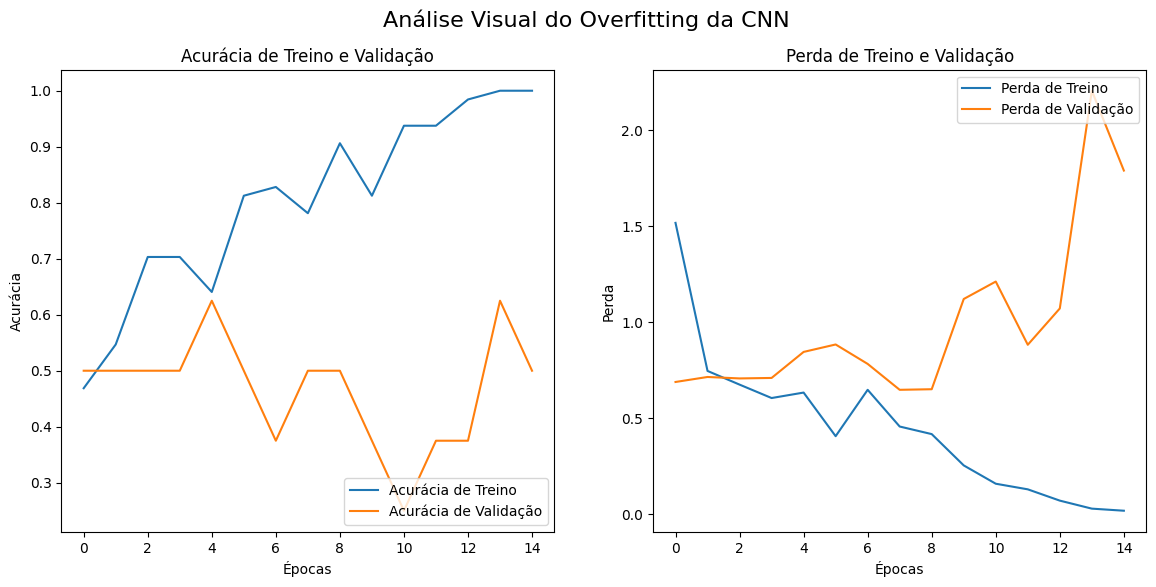

In [11]:
import matplotlib.pyplot as plt

# Extrair o histórico de acurácia e perda do treinamento
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(len(acc))

# Criar a figura com dois subplots (um para acurácia, um para perda)
plt.figure(figsize=(14, 6))

# Subplot 1: Gráfico de Acurácia
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Acurácia de Treino')
plt.plot(epochs_range, val_acc, label='Acurácia de Validação')
plt.legend(loc='lower right')
plt.title('Acurácia de Treino e Validação')
plt.xlabel('Épocas')
plt.ylabel('Acurácia')

# Subplot 2: Gráfico de Perda
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Perda de Treino')
plt.plot(epochs_range, val_loss, label='Perda de Validação')
plt.legend(loc='upper right')
plt.title('Perda de Treino e Validação')
plt.xlabel('Épocas')
plt.ylabel('Perda')

# Exibir os gráficos
plt.suptitle('Análise Visual do Overfitting da CNN', fontsize=16)
plt.show()

# 3.2. Análise Crítica e Comparativa das Abordagens

A segunda entrega deste projeto teve como objetivo comparar a performance do nosso modelo **YOLOv5 Customizado** com outras duas abordagens populares: um modelo **YOLOv5 Padrão** (pré-treinado) e uma **Rede Neural Convolucional (CNN)** treinada do zero para classificação. A análise a seguir avalia os três modelos sob quatro critérios fundamentais para determinar a melhor solução para o cliente FarmTech.

### Tabela Comparativa de Resultados

| Critério | YOLOv5 Customizado (Entrega 1) | YOLOv5 Padrão (Pré-treinado) | CNN do Zero (Classificação) |
| :--- | :--- | :--- | :--- |
| **Facilidade de Uso** | Médio (requer rotulação e treino) | **Muito Fácil** (plug-and-play) | Difícil (requer design de arquitetura) |
| **Precisão** | Boa (`mAP@.50 = 0.85`), mas cometeu erro de classificação. **Detecta e Localiza.** | **Excelente** (100% de acertos nos testes). **Detecta e Localiza.** | Muito Baixa (`val_accuracy < 50%`) devido a overfitting. **Apenas Classifica.** |
| **Tempo de Treinamento**| ~10-15 minutos (para 60 épocas) | **N/A** (modelo pronto) | Rápido (~2 minutos) |
| **Tempo de Inferência**| Rápido (~194ms / imagem) | Rápido (~318ms / imagem) | **Muito Rápido** (< 50ms / imagem) |

---

### Análise Crítica Detalhada

#### 1. O Poder dos Dados: YOLO Padrão vs. Customizado
A descoberta mais surpreendente foi a performance superior do **YOLOv5 Padrão**. Sem nenhum treinamento adicional, ele identificou corretamente 100% dos cães e gatos em nosso conjunto de teste, superando nosso modelo customizado que, apesar de um bom `mAP`, falhou em algumas detecções e classificou um gato como cachorro.

**Conclusão:** Isso demonstra uma verdade fundamental em Machine Learning: **a qualidade e a quantidade de dados superam, muitas vezes, a customização do modelo**. O YOLOv5 padrão foi treinado no dataset COCO, que contém milhares de imagens de cães e gatos, tornando-o um especialista robusto nessas classes. Nosso modelo, treinado com apenas 64 imagens, aprendeu padrões específicos do nosso pequeno dataset, o que levou a um leve overfitting e a erros de generalização.

#### 2. O Risco do Overfitting: A Lição da CNN
A tentativa de treinar uma **CNN do zero** serviu como um estudo de caso sobre os perigos do overfitting. A análise da arquitetura (`model.summary()`) revelou que nosso modelo possuía mais de **19 milhões de parâmetros**, uma capacidade de aprendizado imensa. Ao treinar esse modelo complexo com apenas 64 imagens, o resultado foi inevitável: o modelo não aprendeu a generalizar, ele simplesmente **decorou** os dados de treino. Isso foi evidenciado pela acurácia de treino atingindo 100%, enquanto a acurácia de validação permaneceu extremamente baixa.

**Conclusão:** A abordagem de treinar uma rede do zero é inviável para datasets pequenos sem técnicas avançadas de regularização ou aumento de dados (*data augmentation*). Além disso, a CNN realiza apenas a **classificação** (dizendo "há um gato na imagem"), enquanto o YOLO realiza a **detecção** (dizendo "há um gato *neste local* da imagem"), uma função muito mais valiosa para os cenários da FarmTech.

---

### Recomendação Final para a FarmTech Solutions

Com base na análise comparativa, a recomendação para a FarmTech depende diretamente do cenário de aplicação:

1.  **Para Detecção de Objetos Comuns:** A melhor solução é, sem dúvida, o **YOLOv5 Padrão**. Para tarefas que envolvem objetos universalmente conhecidos (como pessoas, carros, cães, gatos), este modelo oferece altíssima precisão, custo zero de treinamento e implementação imediata.

2.  **Para Detecção de Objetos Específicos e Proprietários:** O **YOLOv5 Customizado** é a abordagem correta. Se a FarmTech precisar detectar objetos que não existem no mundo geral (ex: "tratores modelo X", "gado da raça Nelore", "pragas específicas da lavoura"), o processo de coletar, rotular e treinar um modelo customizado é essencial e agrega um valor de negócio imenso.

3.  **Para Classificação de Imagens:** A **CNN** só deve ser considerada se a tarefa for puramente classificar uma imagem inteira em uma categoria, e desde que haja um dataset com milhares de exemplos disponíveis para evitar o overfitting.

Para o problema proposto de detecção de cães e gatos, o modelo pré-treinado se mostrou a solução mais eficiente e precisa.